# Modular Automated Log Analysis for MITRE ATT&CK Mapping

This notebook ingests `cybersecurity_threat_detection_logs.csv`, normalizes the log data, applies modular detection rules, maps alerts to MITRE ATT&CK metadata, and creates summary visualizations.

`threat_label` is not used by any detection rule. It is only available for optional validation after alerts have already been generated.

## Run All

Use **Run All** to execute the notebook from top to bottom.

- **JupyterLab / Jupyter Notebook:** `Run > Run All Cells`
- **VS Code:** `Run All` from the notebook toolbar

Optional helper button: run the next code cell to display a clickable notebook-side button that triggers **Run All Cells** in classic Notebook/JupyterLab-compatible frontends.

In [13]:
from IPython.display import HTML, display

display(HTML("""
<button onclick="Jupyter.notebook.execute_all_cells()" 
        style="font-size:16px; padding:8px 14px; border-radius:6px;">
    Run All Cells
</button>
<p><em>If this button does not work in your frontend, use the notebook toolbar's Run All command.</em></p>
"""))

## 1. Setup


In [14]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List

import pandas as pd
import matplotlib.pyplot as plt

## 2. Configuration

Set `CSV_PATHS` to one or more dataset file paths.

Examples:

```python
CSV_PATHS = ["cybersecurity_threat_detection_logs.csv"]
CSV_PATHS = ["firewall_logs.csv", "application_logs.csv"]
CSV_PATHS = [r"C:\\Users\\YourName\\Downloads\\cybersecurity_threat_detection_logs.csv"]
```

`all_alerts` is initialized here as an empty alert table. Each detection appends its result to that table, so the notebook no longer depends on a later manual `pd.concat()` list.

In [15]:
CSV_PATHS = ["cybersecurity_threat_detection_logs.csv"]
USE_SYNTHETIC_FALLBACK = True

# Detection thresholds. Tune these after inspecting your dataset.
BLOCKED_PROBE_THRESHOLD = 5
LOGIN_PATH_THRESHOLD = 5
SENSITIVE_PATH_BYTES_THRESHOLD = 10000
RARE_PAIR_THRESHOLD = 1
RARE_PROTOCOL_THRESHOLD = 2
FANOUT_DESTINATION_THRESHOLD = 5
BYTE_OUTLIER_QUANTILE = 0.95
TIME_CLUSTER_THRESHOLD = 10
TIME_BUCKET = "1D"

# Global alert accumulator. Each detection section appends to this table.
ALERT_COLUMNS = [
    "detection_name",
    "severity",
    "timestamp",
    "source_ip",
    "dest_ip",
    "protocol",
    "description",
    "evidence",
    "mitre_technique_id",
    "mitre_technique",
    "mitre_tactic",
]

all_alerts = pd.DataFrame(columns=ALERT_COLUMNS)


def append_alerts(existing_alerts: pd.DataFrame, new_alerts: pd.DataFrame) -> pd.DataFrame:
    """Append detection results while safely handling empty results."""
    if new_alerts is None or new_alerts.empty:
        return existing_alerts.copy()

    if existing_alerts is None or existing_alerts.empty:
        combined = new_alerts.copy()
    else:
        combined = pd.concat([existing_alerts, new_alerts], ignore_index=True)

    if "timestamp" in combined.columns and not combined.empty:
        combined = combined.sort_values("timestamp").reset_index(drop=True)

    return combined

## 3. MITRE ATT&CK Mapping

MITRE ATT&CK reference: https://attack.mitre.org/

The mappings below attach ATT&CK metadata to each detection family.

In [16]:
MITRE_MAPPINGS = {
    "ACTIVE_SCANNING": {
        "technique_id": "T1595",
        "technique": "Active Scanning",
        "tactic": "Reconnaissance",
        "url": "https://attack.mitre.org/techniques/T1595/",
    },
    "VULN_SCANNING": {
        "technique_id": "T1595.002",
        "technique": "Active Scanning: Vulnerability Scanning",
        "tactic": "Reconnaissance",
        "url": "https://attack.mitre.org/techniques/T1595/002/",
    },
    "BRUTE_FORCE_PROXY": {
        "technique_id": "T1110",
        "technique": "Brute Force",
        "tactic": "Credential Access",
        "url": "https://attack.mitre.org/techniques/T1110/",
    },
    "APPLICATION_LAYER_PROTOCOL": {
        "technique_id": "T1071",
        "technique": "Application Layer Protocol",
        "tactic": "Command and Control",
        "url": "https://attack.mitre.org/techniques/T1071/",
    },
    "EXFILTRATION_OVER_WEB_SERVICE": {
        "technique_id": "T1567",
        "technique": "Exfiltration Over Web Service",
        "tactic": "Exfiltration",
        "url": "https://attack.mitre.org/techniques/T1567/",
    },
    "NETWORK_SERVICE_DISCOVERY": {
        "technique_id": "T1046",
        "technique": "Network Service Discovery",
        "tactic": "Discovery",
        "url": "https://attack.mitre.org/techniques/T1046/",
    },
    "NON_APPLICATION_LAYER_PROTOCOL": {
        "technique_id": "T1095",
        "technique": "Non-Application Layer Protocol",
        "tactic": "Command and Control",
        "url": "https://attack.mitre.org/techniques/T1095/",
    },
    "EXFILTRATION_OVER_C2": {
        "technique_id": "T1041",
        "technique": "Exfiltration Over C2 Channel",
        "tactic": "Exfiltration",
        "url": "https://attack.mitre.org/techniques/T1041/",
    },
}

## 5. CSV Ingestion and Normalization


In [36]:
#Modify CSV_PATH in 2.Configuration to use your own dataset

REQUIRED_COLUMNS = {
    "timestamp",
    "source_ip",
    "dest_ip",
    "protocol",
    "action",
    "log_type",
    "bytes_transferred",
    "user_agent",
    "request_path",
}

def create_synthetic_csv_style_logs() -> pd.DataFrame:
    """Create a small synthetic dataset matching the CSV project schema."""
    rows = [
        {
            "timestamp": "2024-05-01T00:00:00",
            "source_ip": "192.168.1.125",
            "dest_ip": "192.168.1.124",
            "protocol": "TCP",
            "action": "blocked",
            "threat_label": "benign",
            "log_type": "firewall",
            "bytes_transferred": 10889,
            "user_agent": "Nmap Scripting Engine",
            "request_path": "/",
        },
        {
            "timestamp": "2024-03-08T00:00:00",
            "source_ip": "192.168.1.77",
            "dest_ip": "192.168.1.118",
            "protocol": "UDP",
            "action": "allowed",
            "threat_label": "benign",
            "log_type": "firewall",
            "bytes_transferred": 30134,
            "user_agent": "SQLMap/1.6-dev",
            "request_path": "/",
        },
        {
            "timestamp": "2024-12-02T00:00:00",
            "source_ip": "192.168.1.134",
            "dest_ip": "192.168.1.81",
            "protocol": "FTP",
            "action": "allowed",
            "threat_label": "benign",
            "log_type": "application",
            "bytes_transferred": 15742,
            "user_agent": "curl/7.64.1",
            "request_path": "/backup",
        },
    ]

    for i in range(6):
        rows.append(
            {
                "timestamp": f"2024-04-07T00:0{i}:00",
                "source_ip": "198.51.100.25",
                "dest_ip": "192.168.1.15",
                "protocol": "HTTP",
                "action": "allowed",
                "threat_label": "unknown",
                "log_type": "application",
                "bytes_transferred": 4500 + i,
                "user_agent": "Mozilla/5.0",
                "request_path": "/login",
            }
        )

    for i in range(12):
        rows.append(
            {
                "timestamp": f"2024-05-01T00:{10+i:02d}:00",
                "source_ip": "203.0.113.44",
                "dest_ip": f"192.168.1.{100+i}",
                "protocol": "TCP",
                "action": "blocked",
                "threat_label": "unknown",
                "log_type": "firewall",
                "bytes_transferred": 1000 + i,
                "user_agent": "unknown",
                "request_path": "/",
            }
        )

    return pd.DataFrame(rows)

def load_security_logs(csv_paths: str, use_synthetic_fallback: bool = False) -> pd.DataFrame:
    """Load and normalize security logs from CSV.

    Args:
        csv_path: Path to the CSV dataset.
        use_synthetic_fallback: If True, use demo data when CSV is missing.

    Returns:
        Normalized security log DataFrame.
    """
    for csv_path in csv_paths:
        path = Path(csv_path)

        if path.exists():
            df = pd.read_csv(path)
            print(f"Loaded CSV dataset from: {path}")
        elif use_synthetic_fallback:
            df = create_synthetic_csv_style_logs()
            print("CSV not found. Using synthetic fallback dataset.")
        else:
            raise FileNotFoundError(f"CSV file not found: {path}")

        missing_columns = REQUIRED_COLUMNS.difference(df.columns)
        if missing_columns:
            raise ValueError(f"Dataset is missing required columns: {sorted(missing_columns)}")

    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"])
    df["source_ip"] = df["source_ip"].astype(str).str.strip()
    df["dest_ip"] = df["dest_ip"].astype(str).str.strip()
    df["protocol"] = df["protocol"].astype(str).str.upper().str.strip()
    df["action"] = df["action"].astype(str).str.lower().str.strip()
    df["log_type"] = df["log_type"].astype(str).str.lower().str.strip()
    df["bytes_transferred"] = pd.to_numeric(df["bytes_transferred"], errors="coerce").fillna(0)
    df["user_agent"] = df["user_agent"].fillna("").astype(str)
    df["request_path"] = df["request_path"].fillna("").astype(str)
    df["time_bucket"] = df["timestamp"].dt.floor(TIME_BUCKET)
    df["hour"] = df["timestamp"].dt.hour
    df["day_of_week"] = df["timestamp"].dt.day_name()
    df["date"] = df["timestamp"].dt.date

    if "threat_label" in df.columns:
        print("Note: 'threat_label' is present but excluded from detection logic.")

    return df.sort_values("timestamp").reset_index(drop=True)


logs = load_security_logs(CSV_PATHS, USE_SYNTHETIC_FALLBACK)
logs.head()

CSV not found. Using synthetic fallback dataset.
Note: 'threat_label' is present but excluded from detection logic.


,timestamp,source_ip,dest_ip,protocol,action,threat_label,log_type,bytes_transferred,user_agent,request_path,time_bucket,hour,day_of_week,date
0,2024-03-08 00:00:00,192.168.1.77,192.168.1.118,UDP,allowed,benign,firewall,30134,SQLMap/1.6-dev,/,2024-03-08,0,Friday,2024-03-08
1,2024-04-07 00:00:00,198.51.100.25,192.168.1.15,HTTP,allowed,unknown,application,4500,Mozilla/5.0,/login,2024-04-07,0,Sunday,2024-04-07
2,2024-04-07 00:01:00,198.51.100.25,192.168.1.15,HTTP,allowed,unknown,application,4501,Mozilla/5.0,/login,2024-04-07,0,Sunday,2024-04-07
3,2024-04-07 00:02:00,198.51.100.25,192.168.1.15,HTTP,allowed,unknown,application,4502,Mozilla/5.0,/login,2024-04-07,0,Sunday,2024-04-07
4,2024-04-07 00:03:00,198.51.100.25,192.168.1.15,HTTP,allowed,unknown,application,4503,Mozilla/5.0,/login,2024-04-07,0,Sunday,2024-04-07


## 6. Alert Helper Functions


In [18]:
def attach_mitre(alerts: pd.DataFrame, mapping_key: str) -> pd.DataFrame:
    """Attach MITRE ATT&CK metadata to alert records."""
    if alerts.empty:
        return alerts

    mapping = MITRE_MAPPINGS[mapping_key]
    alerts = alerts.copy()
    alerts["mitre_technique_id"] = mapping["technique_id"]
    alerts["mitre_technique"] = mapping["technique"]
    alerts["mitre_tactic"] = mapping["tactic"]
    alerts["mitre_url"] = mapping["url"]
    return alerts


def build_alert(
    detection_name: str,
    severity: str,
    timestamp: pd.Timestamp,
    source_ip: str,
    dest_ip: str,
    protocol: str,
    description: str,
    evidence: Dict,
) -> Dict:
    """Build a normalized alert record."""
    return {
        "detection_name": detection_name,
        "severity": severity,
        "timestamp": timestamp,
        "source_ip": source_ip,
        "dest_ip": dest_ip,
        "protocol": protocol,
        "description": description,
        "evidence": evidence,
    }

## 7. Detection 1 — Scanner Tool User Agent


In [19]:
def detect_scanner_user_agents(df: pd.DataFrame) -> pd.DataFrame:
    """Detect scanner or offensive security tool user agents."""
    scanner_indicators = [
        "nmap", "sqlmap", "nikto", "masscan", "nessus", "openvas",
        "zap", "burp", "acunetix", "dirbuster", "gobuster", "ffuf",
    ]
    alerts: List[Dict] = []

    for _, event in df.iterrows():
        user_agent = str(event["user_agent"]).lower()
        matches = [indicator for indicator in scanner_indicators if indicator in user_agent]
        if matches:
            alerts.append(build_alert(
                "Scanner Tool User Agent", "Medium", event["timestamp"],
                event["source_ip"], event["dest_ip"], event["protocol"],
                "User agent contains known scanner or offensive security tooling indicators.",
                {"user_agent": event["user_agent"], "matched_indicators": matches,
                 "request_path": event["request_path"], "action": event["action"]},
            ))
    return attach_mitre(pd.DataFrame(alerts), "VULN_SCANNING")


scanner_alerts = detect_scanner_user_agents(logs)
scanner_alerts

all_alerts = append_alerts(all_alerts, scanner_alerts)
scanner_alerts

,detection_name,severity,timestamp,source_ip,dest_ip,protocol,description,evidence,mitre_technique_id,mitre_technique,mitre_tactic,mitre_url
0,Scanner Tool User Agent,Medium,2024-03-08,192.168.1.77,192.168.1.118,UDP,User agent contains known scanner or offensive...,"{'user_agent': 'SQLMap/1.6-dev', 'matched_indi...",T1595.002,Active Scanning: Vulnerability Scanning,Reconnaissance,https://attack.mitre.org/techniques/T1595/002/
1,Scanner Tool User Agent,Medium,2024-05-01,192.168.1.125,192.168.1.124,TCP,User agent contains known scanner or offensive...,"{'user_agent': 'Nmap Scripting Engine', 'match...",T1595.002,Active Scanning: Vulnerability Scanning,Reconnaissance,https://attack.mitre.org/techniques/T1595/002/


## 8. Detection 2 — Blocked Probe Burst


In [20]:
def detect_blocked_probe_bursts(df: pd.DataFrame, threshold: int = BLOCKED_PROBE_THRESHOLD) -> pd.DataFrame:
    """Detect repeated blocked events from the same source."""
    blocked = df[df["action"] == "blocked"].copy()
    if blocked.empty:
        return pd.DataFrame()

    grouped = blocked.groupby(["time_bucket", "source_ip"]).agg(
        blocked_count=("action", "size"),
        dest_ips=("dest_ip", lambda s: sorted(set(s))),
        protocols=("protocol", lambda s: sorted(set(s))),
        first_seen=("timestamp", "min"),
        last_seen=("timestamp", "max"),
    ).reset_index()

    alerts: List[Dict] = []
    for _, row in grouped[grouped["blocked_count"] >= threshold].iterrows():
        alerts.append(build_alert(
            "Blocked Probe Burst", "High", row["first_seen"], row["source_ip"],
            "multiple", "multiple", "Repeated blocked events from the same source may indicate probing or scanning.",
            {"blocked_count": int(row["blocked_count"]), "dest_ips": row["dest_ips"],
             "protocols": row["protocols"], "first_seen": str(row["first_seen"]),
             "last_seen": str(row["last_seen"]), "time_bucket": str(row["time_bucket"])}
        ))
    return attach_mitre(pd.DataFrame(alerts), "ACTIVE_SCANNING")


blocked_probe_alerts = detect_blocked_probe_bursts(logs)
blocked_probe_alerts

all_alerts = append_alerts(all_alerts, blocked_probe_alerts)
blocked_probe_alerts

,detection_name,severity,timestamp,source_ip,dest_ip,protocol,description,evidence,mitre_technique_id,mitre_technique,mitre_tactic,mitre_url
0,Blocked Probe Burst,High,2024-05-01 00:10:00,203.0.113.44,multiple,multiple,Repeated blocked events from the same source m...,"{'blocked_count': 12, 'dest_ips': ['192.168.1....",T1595,Active Scanning,Reconnaissance,https://attack.mitre.org/techniques/T1595/


## 9. Detection 3 — Login Endpoint Probing


In [21]:
def detect_login_endpoint_probing(df: pd.DataFrame, threshold: int = LOGIN_PATH_THRESHOLD) -> pd.DataFrame:
    """Detect repeated access to login-related request paths."""
    login_keywords = ["login", "signin", "auth", "wp-login", "admin"]
    login_events = df[df["request_path"].str.lower().apply(lambda p: any(k in p for k in login_keywords))].copy()
    if login_events.empty:
        return pd.DataFrame()

    grouped = login_events.groupby(["time_bucket", "source_ip", "dest_ip"]).agg(
        login_path_count=("request_path", "size"),
        request_paths=("request_path", lambda s: sorted(set(s))),
        user_agents=("user_agent", lambda s: sorted(set(s))),
        first_seen=("timestamp", "min"),
        last_seen=("timestamp", "max"),
    ).reset_index()

    alerts: List[Dict] = []
    for _, row in grouped[grouped["login_path_count"] >= threshold].iterrows():
        alerts.append(build_alert(
            "Login Endpoint Probing", "High", row["first_seen"], row["source_ip"], row["dest_ip"],
            "HTTP", "Repeated access to login or authentication paths from one source.",
            {"login_path_count": int(row["login_path_count"]), "request_paths": row["request_paths"],
             "user_agents": row["user_agents"], "first_seen": str(row["first_seen"]),
             "last_seen": str(row["last_seen"]), "time_bucket": str(row["time_bucket"])}
        ))
    return attach_mitre(pd.DataFrame(alerts), "BRUTE_FORCE_PROXY")


login_probe_alerts = detect_login_endpoint_probing(logs)
login_probe_alerts

all_alerts = append_alerts(all_alerts, login_probe_alerts)
login_probe_alerts

,detection_name,severity,timestamp,source_ip,dest_ip,protocol,description,evidence,mitre_technique_id,mitre_technique,mitre_tactic,mitre_url
0,Login Endpoint Probing,High,2024-04-07,198.51.100.25,192.168.1.15,HTTP,Repeated access to login or authentication pat...,"{'login_path_count': 6, 'request_paths': ['/lo...",T1110,Brute Force,Credential Access,https://attack.mitre.org/techniques/T1110/


## 10. Detection 4 — Suspicious Web Tooling or Payload Indicators


In [22]:
def detect_suspicious_web_payloads(df: pd.DataFrame) -> pd.DataFrame:
    """Detect suspicious web tooling or payload indicators."""
    suspicious_user_agents = ["curl", "wget", "python-requests", "go-http-client", "sqlmap", "nmap"]
    suspicious_path_indicators = [
        "../", "%2e%2e", "union select", "select+", " or 1=1", "' or '1'='1",
        "cmd=", "exec=", "powershell", "/etc/passwd", "webshell", ".php?",
    ]
    alerts: List[Dict] = []

    for _, event in df.iterrows():
        user_agent = str(event["user_agent"]).lower()
        request_path = str(event["request_path"]).lower()
        ua_matches = [item for item in suspicious_user_agents if item in user_agent]
        path_matches = [item for item in suspicious_path_indicators if item in request_path]
        if ua_matches or path_matches:
            alerts.append(build_alert(
                "Suspicious Web Tooling or Payload Indicator", "Medium", event["timestamp"],
                event["source_ip"], event["dest_ip"], event["protocol"],
                "Request contains suspicious tooling or payload indicators.",
                {"user_agent": event["user_agent"], "request_path": event["request_path"],
                 "user_agent_matches": ua_matches, "path_matches": path_matches,
                 "bytes_transferred": float(event["bytes_transferred"]), "action": event["action"]},
            ))
    return attach_mitre(pd.DataFrame(alerts), "APPLICATION_LAYER_PROTOCOL")


web_payload_alerts = detect_suspicious_web_payloads(logs)
web_payload_alerts

all_alerts = append_alerts(all_alerts, web_payload_alerts)
web_payload_alerts

,detection_name,severity,timestamp,source_ip,dest_ip,protocol,description,evidence,mitre_technique_id,mitre_technique,mitre_tactic,mitre_url
0,Suspicious Web Tooling or Payload Indicator,Medium,2024-03-08,192.168.1.77,192.168.1.118,UDP,Request contains suspicious tooling or payload...,"{'user_agent': 'SQLMap/1.6-dev', 'request_path...",T1071,Application Layer Protocol,Command and Control,https://attack.mitre.org/techniques/T1071/
1,Suspicious Web Tooling or Payload Indicator,Medium,2024-05-01,192.168.1.125,192.168.1.124,TCP,Request contains suspicious tooling or payload...,"{'user_agent': 'Nmap Scripting Engine', 'reque...",T1071,Application Layer Protocol,Command and Control,https://attack.mitre.org/techniques/T1071/
2,Suspicious Web Tooling or Payload Indicator,Medium,2024-12-02,192.168.1.134,192.168.1.81,FTP,Request contains suspicious tooling or payload...,"{'user_agent': 'curl/7.64.1', 'request_path': ...",T1071,Application Layer Protocol,Command and Control,https://attack.mitre.org/techniques/T1071/


## 11. Detection 5 — High-Volume Sensitive Path Access


In [23]:
def detect_high_volume_sensitive_path_access(df: pd.DataFrame, bytes_threshold: int = SENSITIVE_PATH_BYTES_THRESHOLD) -> pd.DataFrame:
    """Detect high-volume transfers involving sensitive paths."""
    sensitive_path_keywords = [
        "backup", "export", "dump", "archive", "database", "db", "admin",
        "config", "secrets", "credentials",
    ]
    alerts: List[Dict] = []

    for _, event in df.iterrows():
        request_path = str(event["request_path"]).lower()
        bytes_transferred = float(event["bytes_transferred"])
        matches = [keyword for keyword in sensitive_path_keywords if keyword in request_path]
        if matches and bytes_transferred >= bytes_threshold:
            alerts.append(build_alert(
                "High-Volume Sensitive Path Access", "High", event["timestamp"], event["source_ip"],
                event["dest_ip"], event["protocol"], "Large data transfer involving sensitive-looking path.",
                {"request_path": event["request_path"], "matched_keywords": matches,
                 "bytes_transferred": bytes_transferred, "bytes_threshold": bytes_threshold,
                 "user_agent": event["user_agent"], "action": event["action"]},
            ))
    return attach_mitre(pd.DataFrame(alerts), "EXFILTRATION_OVER_WEB_SERVICE")


sensitive_path_alerts = detect_high_volume_sensitive_path_access(logs)
sensitive_path_alerts

all_alerts = append_alerts(all_alerts, sensitive_path_alerts)
sensitive_path_alerts

,detection_name,severity,timestamp,source_ip,dest_ip,protocol,description,evidence,mitre_technique_id,mitre_technique,mitre_tactic,mitre_url
0,High-Volume Sensitive Path Access,High,2024-12-02,192.168.1.134,192.168.1.81,FTP,Large data transfer involving sensitive-lookin...,"{'request_path': '/backup', 'matched_keywords'...",T1567,Exfiltration Over Web Service,Exfiltration,https://attack.mitre.org/techniques/T1567/


## 12. Stretch Detection 6 — Rare Source/Destination Pair Detection


In [24]:
def detect_rare_source_destination_pairs(
    df: pd.DataFrame,
    max_pair_count: int = RARE_PAIR_THRESHOLD,
    source_activity_threshold: int = RARE_PROTOCOL_THRESHOLD,
) -> pd.DataFrame:
    """Detect rare source/destination pairs from otherwise active sources."""
    pair_counts = df.groupby(["source_ip", "dest_ip"]).size().reset_index(name="pair_count")
    source_counts = df.groupby("source_ip").size().reset_index(name="source_event_count")
    enriched = pair_counts.merge(source_counts, on="source_ip", how="left")
    rare_pairs = enriched[
        (enriched["pair_count"] <= max_pair_count)
        & (enriched["source_event_count"] >= source_activity_threshold)
    ]

    alerts: List[Dict] = []
    for _, row in rare_pairs.iterrows():
        sample = df[(df["source_ip"] == row["source_ip"]) & (df["dest_ip"] == row["dest_ip"])].iloc[0]
        alerts.append(build_alert(
            "Rare Source/Destination Pair", "Low", sample["timestamp"], row["source_ip"], row["dest_ip"],
            sample["protocol"], "An active source communicated with a rarely observed destination.",
            {"pair_count": int(row["pair_count"]), "source_event_count": int(row["source_event_count"]),
             "max_pair_count": max_pair_count, "source_activity_threshold": source_activity_threshold},
        ))
    return attach_mitre(pd.DataFrame(alerts), "NETWORK_SERVICE_DISCOVERY")


rare_pair_alerts = detect_rare_source_destination_pairs(logs)
rare_pair_alerts.head(20)

all_alerts = append_alerts(all_alerts, rare_pair_alerts)
rare_pair_alerts

,detection_name,severity,timestamp,source_ip,dest_ip,protocol,description,evidence,mitre_technique_id,mitre_technique,mitre_tactic,mitre_url
0,Rare Source/Destination Pair,Low,2024-05-01 00:10:00,203.0.113.44,192.168.1.100,TCP,An active source communicated with a rarely ob...,"{'pair_count': 1, 'source_event_count': 12, 'm...",T1046,Network Service Discovery,Discovery,https://attack.mitre.org/techniques/T1046/
1,Rare Source/Destination Pair,Low,2024-05-01 00:11:00,203.0.113.44,192.168.1.101,TCP,An active source communicated with a rarely ob...,"{'pair_count': 1, 'source_event_count': 12, 'm...",T1046,Network Service Discovery,Discovery,https://attack.mitre.org/techniques/T1046/
2,Rare Source/Destination Pair,Low,2024-05-01 00:12:00,203.0.113.44,192.168.1.102,TCP,An active source communicated with a rarely ob...,"{'pair_count': 1, 'source_event_count': 12, 'm...",T1046,Network Service Discovery,Discovery,https://attack.mitre.org/techniques/T1046/
3,Rare Source/Destination Pair,Low,2024-05-01 00:13:00,203.0.113.44,192.168.1.103,TCP,An active source communicated with a rarely ob...,"{'pair_count': 1, 'source_event_count': 12, 'm...",T1046,Network Service Discovery,Discovery,https://attack.mitre.org/techniques/T1046/
4,Rare Source/Destination Pair,Low,2024-05-01 00:14:00,203.0.113.44,192.168.1.104,TCP,An active source communicated with a rarely ob...,"{'pair_count': 1, 'source_event_count': 12, 'm...",T1046,Network Service Discovery,Discovery,https://attack.mitre.org/techniques/T1046/
5,Rare Source/Destination Pair,Low,2024-05-01 00:15:00,203.0.113.44,192.168.1.105,TCP,An active source communicated with a rarely ob...,"{'pair_count': 1, 'source_event_count': 12, 'm...",T1046,Network Service Discovery,Discovery,https://attack.mitre.org/techniques/T1046/
6,Rare Source/Destination Pair,Low,2024-05-01 00:16:00,203.0.113.44,192.168.1.106,TCP,An active source communicated with a rarely ob...,"{'pair_count': 1, 'source_event_count': 12, 'm...",T1046,Network Service Discovery,Discovery,https://attack.mitre.org/techniques/T1046/
7,Rare Source/Destination Pair,Low,2024-05-01 00:17:00,203.0.113.44,192.168.1.107,TCP,An active source communicated with a rarely ob...,"{'pair_count': 1, 'source_event_count': 12, 'm...",T1046,Network Service Discovery,Discovery,https://attack.mitre.org/techniques/T1046/
8,Rare Source/Destination Pair,Low,2024-05-01 00:18:00,203.0.113.44,192.168.1.108,TCP,An active source communicated with a rarely ob...,"{'pair_count': 1, 'source_event_count': 12, 'm...",T1046,Network Service Discovery,Discovery,https://attack.mitre.org/techniques/T1046/
9,Rare Source/Destination Pair,Low,2024-05-01 00:19:00,203.0.113.44,192.168.1.109,TCP,An active source communicated with a rarely ob...,"{'pair_count': 1, 'source_event_count': 12, 'm...",T1046,Network Service Discovery,Discovery,https://attack.mitre.org/techniques/T1046/


## 13. Stretch Detection 9 — High Byte Transfer Outliers


In [25]:
def detect_high_byte_transfer_outliers(
    df: pd.DataFrame,
    quantile: float = BYTE_OUTLIER_QUANTILE,
) -> pd.DataFrame:
    """Detect high byte transfer outliers by source/destination pair."""
    if df.empty:
        return pd.DataFrame()

    threshold = df["bytes_transferred"].quantile(quantile)
    pair_totals = df.groupby(["source_ip", "dest_ip"]).agg(
        total_bytes=("bytes_transferred", "sum"),
        event_count=("timestamp", "size"),
        protocols=("protocol", lambda s: sorted(set(s))),
        first_seen=("timestamp", "min"),
        last_seen=("timestamp", "max"),
    ).reset_index()

    outliers = pair_totals[pair_totals["total_bytes"] >= threshold]
    alerts: List[Dict] = []
    for _, row in outliers.iterrows():
        alerts.append(build_alert(
            "High Byte Transfer Outlier", "High", row["first_seen"], row["source_ip"], row["dest_ip"],
            "multiple", "A source/destination pair transferred an unusually high volume of data.",
            {"total_bytes": float(row["total_bytes"]), "event_count": int(row["event_count"]),
             "protocols": row["protocols"], "quantile": quantile, "threshold": float(threshold),
             "first_seen": str(row["first_seen"]), "last_seen": str(row["last_seen"])},
        ))
    return attach_mitre(pd.DataFrame(alerts), "EXFILTRATION_OVER_C2")


byte_outlier_alerts = detect_high_byte_transfer_outliers(logs)
byte_outlier_alerts.head(20)

all_alerts = append_alerts(all_alerts, byte_outlier_alerts)
byte_outlier_alerts

,detection_name,severity,timestamp,source_ip,dest_ip,protocol,description,evidence,mitre_technique_id,mitre_technique,mitre_tactic,mitre_url
0,High Byte Transfer Outlier,High,2024-12-02,192.168.1.134,192.168.1.81,multiple,A source/destination pair transferred an unusu...,"{'total_bytes': 15742.0, 'event_count': 1, 'pr...",T1041,Exfiltration Over C2 Channel,Exfiltration,https://attack.mitre.org/techniques/T1041/
1,High Byte Transfer Outlier,High,2024-03-08,192.168.1.77,192.168.1.118,multiple,A source/destination pair transferred an unusu...,"{'total_bytes': 30134.0, 'event_count': 1, 'pr...",T1041,Exfiltration Over C2 Channel,Exfiltration,https://attack.mitre.org/techniques/T1041/
2,High Byte Transfer Outlier,High,2024-04-07,198.51.100.25,192.168.1.15,multiple,A source/destination pair transferred an unusu...,"{'total_bytes': 27015.0, 'event_count': 6, 'pr...",T1041,Exfiltration Over C2 Channel,Exfiltration,https://attack.mitre.org/techniques/T1041/


## 14. Combined Alert Results


In [26]:
if all_alerts.empty:
    print("No alerts generated by the current detection rules.")
else:
    all_alerts = all_alerts.sort_values("timestamp").reset_index(drop=True)

all_alerts

,detection_name,severity,timestamp,source_ip,dest_ip,protocol,description,evidence,mitre_technique_id,mitre_technique,mitre_tactic,mitre_url
0,Scanner Tool User Agent,Medium,2024-03-08 00:00:00,192.168.1.77,192.168.1.118,UDP,User agent contains known scanner or offensive...,"{'user_agent': 'SQLMap/1.6-dev', 'matched_indi...",T1595.002,Active Scanning: Vulnerability Scanning,Reconnaissance,https://attack.mitre.org/techniques/T1595/002/
1,Suspicious Web Tooling or Payload Indicator,Medium,2024-03-08 00:00:00,192.168.1.77,192.168.1.118,UDP,Request contains suspicious tooling or payload...,"{'user_agent': 'SQLMap/1.6-dev', 'request_path...",T1071,Application Layer Protocol,Command and Control,https://attack.mitre.org/techniques/T1071/
2,High Byte Transfer Outlier,High,2024-03-08 00:00:00,192.168.1.77,192.168.1.118,multiple,A source/destination pair transferred an unusu...,"{'total_bytes': 30134.0, 'event_count': 1, 'pr...",T1041,Exfiltration Over C2 Channel,Exfiltration,https://attack.mitre.org/techniques/T1041/
3,High Byte Transfer Outlier,High,2024-04-07 00:00:00,198.51.100.25,192.168.1.15,multiple,A source/destination pair transferred an unusu...,"{'total_bytes': 27015.0, 'event_count': 6, 'pr...",T1041,Exfiltration Over C2 Channel,Exfiltration,https://attack.mitre.org/techniques/T1041/
4,Login Endpoint Probing,High,2024-04-07 00:00:00,198.51.100.25,192.168.1.15,HTTP,Repeated access to login or authentication pat...,"{'login_path_count': 6, 'request_paths': ['/lo...",T1110,Brute Force,Credential Access,https://attack.mitre.org/techniques/T1110/
5,Suspicious Web Tooling or Payload Indicator,Medium,2024-05-01 00:00:00,192.168.1.125,192.168.1.124,TCP,Request contains suspicious tooling or payload...,"{'user_agent': 'Nmap Scripting Engine', 'reque...",T1071,Application Layer Protocol,Command and Control,https://attack.mitre.org/techniques/T1071/
6,Scanner Tool User Agent,Medium,2024-05-01 00:00:00,192.168.1.125,192.168.1.124,TCP,User agent contains known scanner or offensive...,"{'user_agent': 'Nmap Scripting Engine', 'match...",T1595.002,Active Scanning: Vulnerability Scanning,Reconnaissance,https://attack.mitre.org/techniques/T1595/002/
7,Blocked Probe Burst,High,2024-05-01 00:10:00,203.0.113.44,multiple,multiple,Repeated blocked events from the same source m...,"{'blocked_count': 12, 'dest_ips': ['192.168.1....",T1595,Active Scanning,Reconnaissance,https://attack.mitre.org/techniques/T1595/
8,Rare Source/Destination Pair,Low,2024-05-01 00:10:00,203.0.113.44,192.168.1.100,TCP,An active source communicated with a rarely ob...,"{'pair_count': 1, 'source_event_count': 12, 'm...",T1046,Network Service Discovery,Discovery,https://attack.mitre.org/techniques/T1046/
9,Rare Source/Destination Pair,Low,2024-05-01 00:11:00,203.0.113.44,192.168.1.101,TCP,An active source communicated with a rarely ob...,"{'pair_count': 1, 'source_event_count': 12, 'm...",T1046,Network Service Discovery,Discovery,https://attack.mitre.org/techniques/T1046/


## 15. Optional Validation Against threat_label


## 16. Export Alert Report


In [27]:
report_path = "mitre_attack_detection_report.csv"

if all_alerts.empty:
    print("No alerts generated. Nothing exported.")
else:
    all_alerts.to_csv(report_path, index=False)
    print(f"Alert report exported to: {report_path}")

Alert report exported to: mitre_attack_detection_report.csv


## 17. Visualization Helper — Heatmap Function


In [28]:
def plot_heatmap(
    pivot_df: pd.DataFrame,
    title: str,
    xlabel: str,
    ylabel: str,
    figsize: tuple = (12, 6),
) -> None:
    """Plot a simple heatmap using matplotlib only.

    Args:
        pivot_df: Pivot table to visualize.
        title: Chart title.
        xlabel: X-axis label.
        ylabel: Y-axis label.
        figsize: Figure size.
    """
    if pivot_df.empty:
        print(f"No data available for heatmap: {title}")
        return

    plt.figure(figsize=figsize)
    plt.imshow(pivot_df, aspect="auto")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(range(len(pivot_df.columns)), pivot_df.columns, rotation=45, ha="right")
    plt.yticks(range(len(pivot_df.index)), pivot_df.index)
    plt.colorbar(label="Event Count")
    plt.tight_layout()
    plt.show()

## 18. Visualization — Alert Count by MITRE Technique


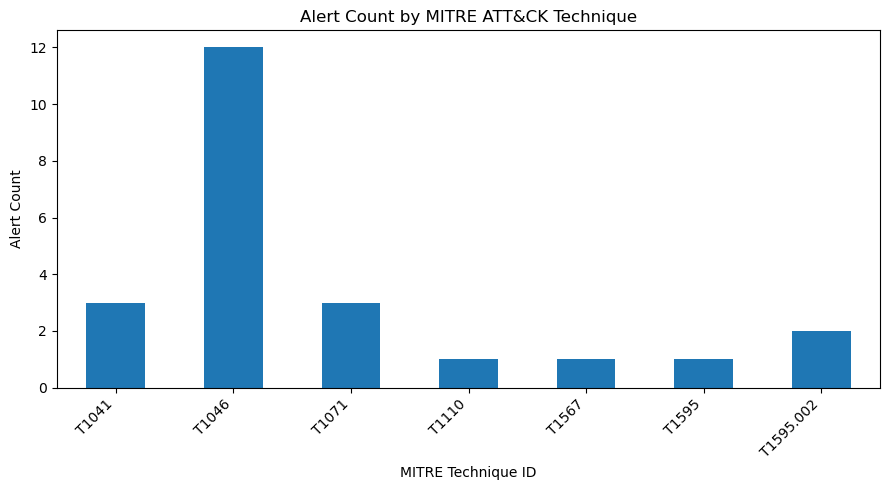

In [29]:
if not all_alerts.empty:
    technique_counts = all_alerts["mitre_technique_id"].value_counts().sort_index()

    plt.figure(figsize=(9, 5))
    technique_counts.plot(kind="bar")
    plt.title("Alert Count by MITRE ATT&CK Technique")
    plt.xlabel("MITRE Technique ID")
    plt.ylabel("Alert Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No alerts to visualize.")

## 19. Visualization — Time of Day Heatmap


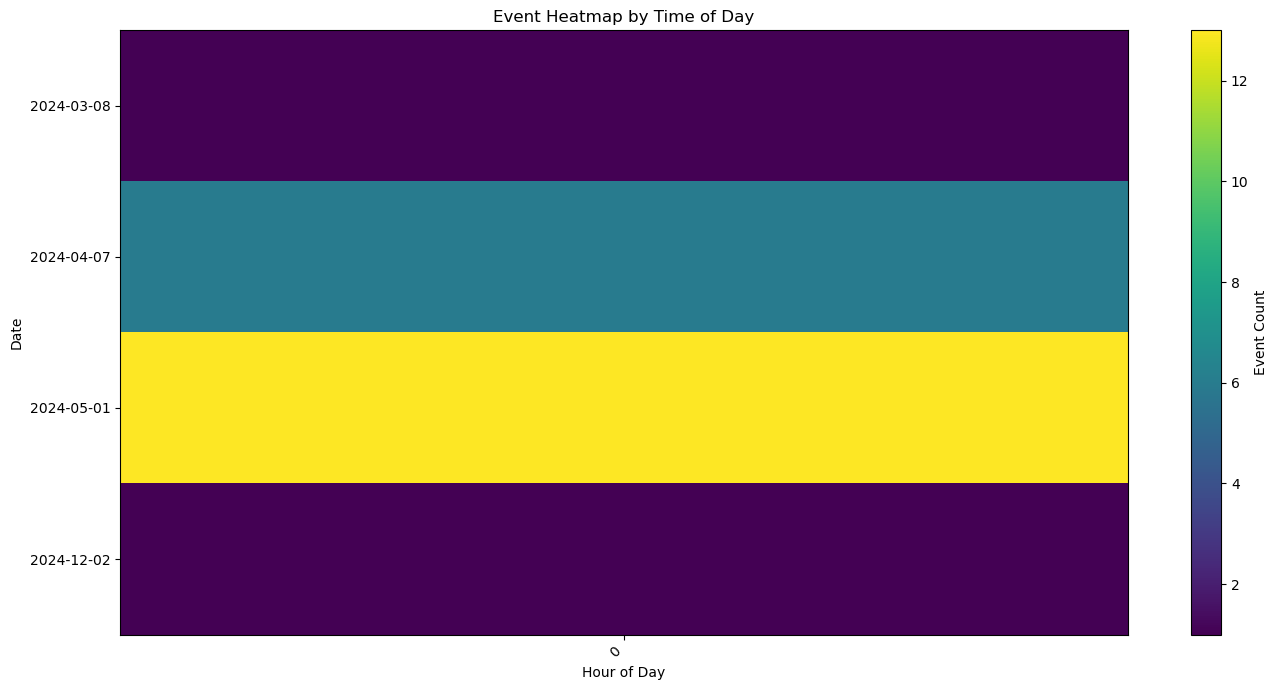

In [30]:
time_of_day_df = logs.copy()
time_of_day_df["hour"] = time_of_day_df["timestamp"].dt.hour
time_of_day_df["event_date"] = time_of_day_df["timestamp"].dt.date

time_of_day_heatmap = (
    time_of_day_df
    .pivot_table(index="event_date", columns="hour", values="source_ip", aggfunc="count", fill_value=0)
)

plot_heatmap(
    time_of_day_heatmap,
    title="Event Heatmap by Time of Day",
    xlabel="Hour of Day",
    ylabel="Date",
    figsize=(14, 7),
)

## 20. Visualization — Day of Week Heatmap


C:\Users\White Iron\AppData\Local\Temp\ipykernel_804\673972096.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(index="day_of_week", columns="hour", values="source_ip", aggfunc="count", fill_value=0)


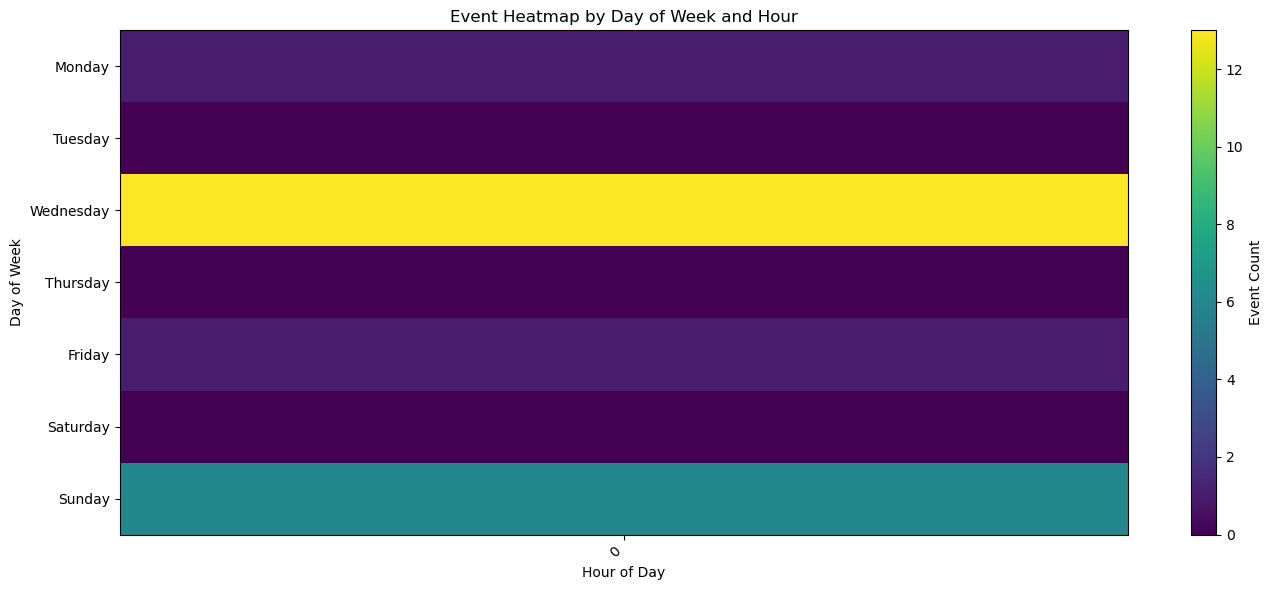

In [31]:
day_of_week_df = logs.copy()
day_of_week_df["day_of_week"] = pd.Categorical(
    day_of_week_df["timestamp"].dt.day_name(),
    categories=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    ordered=True,
)
day_of_week_df["hour"] = day_of_week_df["timestamp"].dt.hour

day_of_week_heatmap = (
    day_of_week_df
    .pivot_table(index="day_of_week", columns="hour", values="source_ip", aggfunc="count", fill_value=0)
)

plot_heatmap(
    day_of_week_heatmap,
    title="Event Heatmap by Day of Week and Hour",
    xlabel="Hour of Day",
    ylabel="Day of Week",
    figsize=(14, 6),
)

## 21. Visualization — Last 30 Days in Dataset


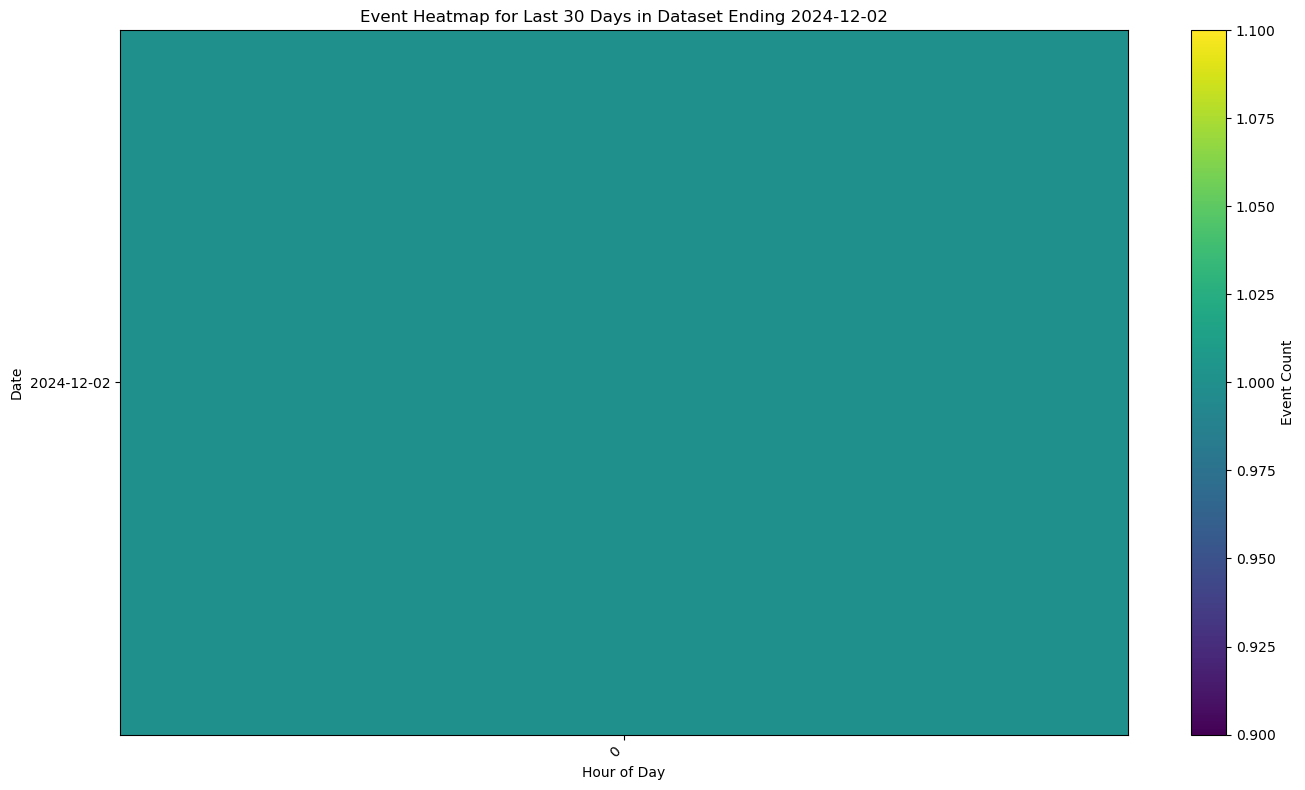

In [32]:
last_timestamp = logs["timestamp"].max()
start_timestamp = last_timestamp - pd.Timedelta(days=30)

last_30_days = logs[logs["timestamp"] >= start_timestamp].copy()
last_30_days["event_date"] = last_30_days["timestamp"].dt.date
last_30_days["hour"] = last_30_days["timestamp"].dt.hour

last_30_heatmap = (
    last_30_days
    .pivot_table(index="event_date", columns="hour", values="source_ip", aggfunc="count", fill_value=0)
)

plot_heatmap(
    last_30_heatmap,
    title=f"Event Heatmap for Last 30 Days in Dataset Ending {last_timestamp.date()}",
    xlabel="Hour of Day",
    ylabel="Date",
    figsize=(14, 8),
)

## 22. Visualization — Events by Protocol


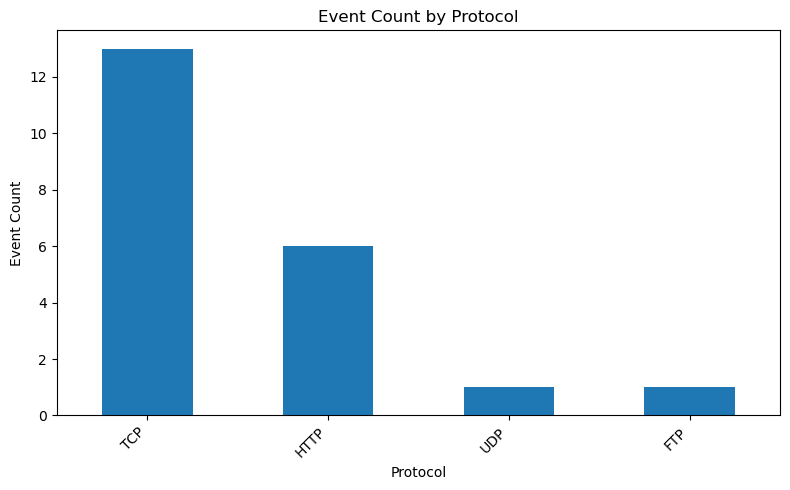

In [33]:
protocol_counts = logs["protocol"].value_counts()

plt.figure(figsize=(8, 5))
protocol_counts.plot(kind="bar")
plt.title("Event Count by Protocol")
plt.xlabel("Protocol")
plt.ylabel("Event Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 23. Source-to-Destination Summary


In [34]:
source_dest_summary = (
    logs.groupby(["source_ip", "dest_ip"])
    .agg(
        event_count=("timestamp", "size"),
        protocols=("protocol", lambda s: sorted(set(s))),
        actions=("action", lambda s: sorted(set(s))),
        total_bytes=("bytes_transferred", "sum"),
        request_paths=("request_path", lambda s: sorted(set(s))[:10]),
        first_seen=("timestamp", "min"),
        last_seen=("timestamp", "max"),
    )
    .reset_index()
    .sort_values(["event_count", "total_bytes"], ascending=[False, False])
)

source_dest_summary.head(20)

,source_ip,dest_ip,event_count,protocols,actions,total_bytes,request_paths,first_seen,last_seen
3,198.51.100.25,192.168.1.15,6,[HTTP],[allowed],27015,[/login],2024-04-07 00:00:00,2024-04-07 00:05:00
2,192.168.1.77,192.168.1.118,1,[UDP],[allowed],30134,[/],2024-03-08 00:00:00,2024-03-08 00:00:00
1,192.168.1.134,192.168.1.81,1,[FTP],[allowed],15742,[/backup],2024-12-02 00:00:00,2024-12-02 00:00:00
0,192.168.1.125,192.168.1.124,1,[TCP],[blocked],10889,[/],2024-05-01 00:00:00,2024-05-01 00:00:00
15,203.0.113.44,192.168.1.111,1,[TCP],[blocked],1011,[/],2024-05-01 00:21:00,2024-05-01 00:21:00
14,203.0.113.44,192.168.1.110,1,[TCP],[blocked],1010,[/],2024-05-01 00:20:00,2024-05-01 00:20:00
13,203.0.113.44,192.168.1.109,1,[TCP],[blocked],1009,[/],2024-05-01 00:19:00,2024-05-01 00:19:00
12,203.0.113.44,192.168.1.108,1,[TCP],[blocked],1008,[/],2024-05-01 00:18:00,2024-05-01 00:18:00
11,203.0.113.44,192.168.1.107,1,[TCP],[blocked],1007,[/],2024-05-01 00:17:00,2024-05-01 00:17:00
10,203.0.113.44,192.168.1.106,1,[TCP],[blocked],1006,[/],2024-05-01 00:16:00,2024-05-01 00:16:00


## 24. Simple Attack Narrative


In [35]:
def summarize_attack_narrative(alerts: pd.DataFrame) -> List[str]:
    """Create a chronological alert narrative."""
    if alerts.empty:
        return ["No suspicious behavior detected by current rules."]

    narrative = []
    for _, row in alerts.sort_values("timestamp").iterrows():
        narrative.append(
            f"{row['timestamp']} | {row['source_ip']} -> {row['dest_ip']} | "
            f"{row['protocol']} | {row['mitre_technique_id']} "
            f"{row['mitre_technique']} | {row['detection_name']}"
        )
    return narrative


for item in summarize_attack_narrative(all_alerts):
    print(item)

2024-03-08 00:00:00 | 192.168.1.77 -> 192.168.1.118 | UDP | T1595.002 Active Scanning: Vulnerability Scanning | Scanner Tool User Agent
2024-03-08 00:00:00 | 192.168.1.77 -> 192.168.1.118 | UDP | T1071 Application Layer Protocol | Suspicious Web Tooling or Payload Indicator
2024-03-08 00:00:00 | 192.168.1.77 -> 192.168.1.118 | multiple | T1041 Exfiltration Over C2 Channel | High Byte Transfer Outlier
2024-04-07 00:00:00 | 198.51.100.25 -> 192.168.1.15 | multiple | T1041 Exfiltration Over C2 Channel | High Byte Transfer Outlier
2024-04-07 00:00:00 | 198.51.100.25 -> 192.168.1.15 | HTTP | T1110 Brute Force | Login Endpoint Probing
2024-05-01 00:00:00 | 192.168.1.125 -> 192.168.1.124 | TCP | T1071 Application Layer Protocol | Suspicious Web Tooling or Payload Indicator
2024-05-01 00:00:00 | 192.168.1.125 -> 192.168.1.124 | TCP | T1595.002 Active Scanning: Vulnerability Scanning | Scanner Tool User Agent
2024-05-01 00:10:00 | 203.0.113.44 -> multiple | multiple | T1595 Active Scanning | Bl